# Baselines and Pipelines

This notebook shows why accuracy is misleading on imbalanced data using `DummyClassifier`, a `DummyRegressor` baseline on diabetes, and a complete `Pipeline` compared against the baseline.

## Import Required Libraries

Import the datasets, dummy estimators, real models and pipeline tools.

In [1]:
# Import the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             r2_score, mean_absolute_error)

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## An Imbalanced Classification Dataset

Create a dataset where 95% of instances belong to one class, the setting where accuracy deceives.

In [2]:
# Generate a heavily imbalanced classification problem.
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=4,
    weights=[0.95, 0.05], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Positive rate: {y.mean():.3f}")

Positive rate: 0.054


## Dummy Classifier Strategies

Several trivial strategies reach high accuracy simply by favouring the majority class, yet their F1 collapses.

In [3]:
# Compare dummy strategies against a real classifier.
rows = []
for strat in ["most_frequent", "stratified", "uniform"]:
    dummy = DummyClassifier(strategy=strat, random_state=42)
    dummy.fit(X_train, y_train)
    p = dummy.predict(X_test)
    rows.append({"model": f"dummy-{strat}",
                 "accuracy": accuracy_score(y_test, p),
                 "f1": f1_score(y_test, p)})

# Fit a real logistic regression for comparison.
logreg = LogisticRegression(max_iter=5000,
                            class_weight="balanced")
logreg.fit(X_train, y_train)
p = logreg.predict(X_test)
rows.append({"model": "logreg",
             "accuracy": accuracy_score(y_test, p),
             "f1": f1_score(y_test, p)})
clf_table = pd.DataFrame(rows)
clf_table.round(3)

,model,accuracy,f1
0,dummy-most_frequent,0.945,0.000
1,dummy-stratified,0.882,0.027
2,dummy-uniform,0.465,0.070
3,logreg,0.663,0.205


## Why Accuracy Is Misleading

A bar chart contrasts accuracy and F1: the majority-class dummy looks accurate but has an F1 near zero.

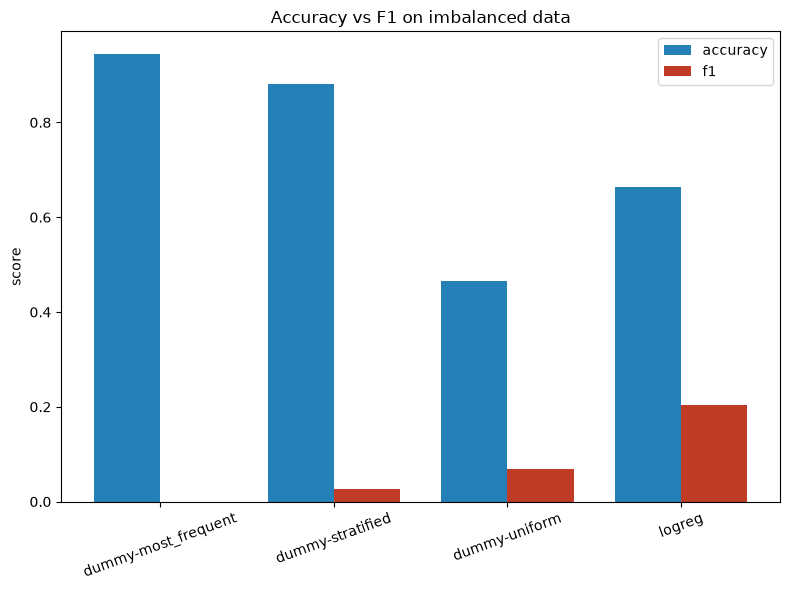

In [4]:
# Plot accuracy against F1 for every classifier.
x = np.arange(len(clf_table))
width = 0.38
plt.figure(figsize=(8, 6))
plt.bar(x - width / 2, clf_table["accuracy"], width,
        color=colors[1], label="accuracy")
plt.bar(x + width / 2, clf_table["f1"], width,
        color=colors[3], label="f1")
plt.xticks(x, clf_table["model"], rotation=20)
plt.title("Accuracy vs F1 on imbalanced data")
plt.ylabel("score")
plt.legend()
plt.tight_layout()
plt.show()

## A Regression Baseline

`DummyRegressor` predicting the mean sets the reference an honest regressor must beat on the diabetes dataset.

In [5]:
# Compare a dummy regressor with a real one on diabetes.
Xd, yd = load_diabetes(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    Xd, yd, test_size=0.3, random_state=42)

dummy_reg = DummyRegressor(strategy="mean").fit(Xd_tr, yd_tr)
real_reg = RandomForestRegressor(
    n_estimators=200, random_state=42).fit(Xd_tr, yd_tr)

print(f"Dummy  R2: {r2_score(yd_te, dummy_reg.predict(Xd_te)):.3f}"
      f", MAE: "
      f"{mean_absolute_error(yd_te, dummy_reg.predict(Xd_te)):.1f}")
print(f"Forest R2: {r2_score(yd_te, real_reg.predict(Xd_te)):.3f}"
      f", MAE: "
      f"{mean_absolute_error(yd_te, real_reg.predict(Xd_te)):.1f}")

Dummy  R2: -0.006, MAE: 64.3
Forest R2: 0.480, MAE: 42.3


## An End-to-End Pipeline

A `ColumnTransformer` inside a `Pipeline` scales the features and fits the model as one reusable object.

In [6]:
# Build a preprocessing and model pipeline.
n_features = X_train.shape[1]
preprocess = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), list(range(n_features))),
])
pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=5000,
                               class_weight="balanced")),
])
pipe.fit(X_train, y_train)
print(f"Pipeline F1: "
      f"{f1_score(y_test, pipe.predict(X_test)):.3f}")

Pipeline F1: 0.205


## Baseline vs Pipeline

A final bar chart reports the F1 improvement of the full pipeline over the majority-class baseline.

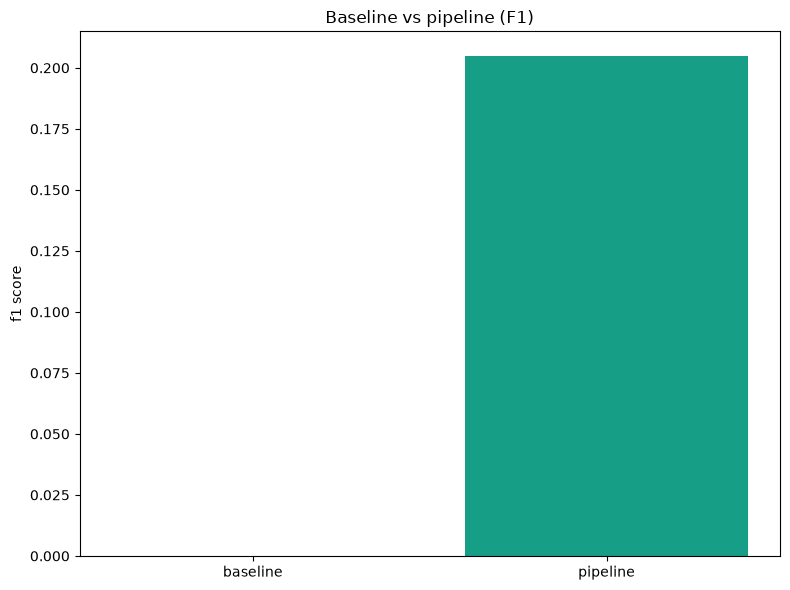

In [7]:
# Compare the baseline and the pipeline by F1.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
scores = {
    "baseline": f1_score(y_test, baseline.predict(X_test)),
    "pipeline": f1_score(y_test, pipe.predict(X_test)),
}
plt.figure(figsize=(8, 6))
plt.bar(scores.keys(), scores.values(),
        color=[colors[4], colors[0]])
plt.title("Baseline vs pipeline (F1)")
plt.ylabel("f1 score")
plt.tight_layout()
plt.show()

## Summary

- **Baselines**: `DummyClassifier` and `DummyRegressor` set the reference every model must beat.
- **Misleading accuracy**: on imbalanced data a trivial model scores high accuracy but near-zero F1.
- **Right metric**: F1 (or balanced metrics) reveal real performance.
- **Pipeline**: `ColumnTransformer` plus estimator bundles preprocessing and modelling into one leak-free object.